# 第4节：数据防御——清洗与增强策略（Cleaning & Augmentation）

本节目标：

1. 将“数据防御”拆成可执行的工程动作：**发现问题 → 标记/隔离 → 修复/替换 → 增强与再训练 → 评估闭环**
2. 掌握三类常用数据清洗思路：
   - 异常样本检测（outlier / low-quality）
   - 近重复/重复样本识别（duplicate / near-duplicate）
   - 训练一致性检验（训练后发现疑似错标/污染）
3. 掌握两类标签修复策略：
   - 基于模型置信度与一致性：筛查疑似错标并修复
   - 伪标签/自训练：利用模型对高置信样本重标
4. 实践数据增强：噪声、平移、遮挡（patch/erasing）、mixup（简化版），并评估对泛化/鲁棒性的影响


## 0. 路径与环境约定

统一使用：

```python
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
```

这样 notebook 永远能读到项目根目录下的资源。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)


CWD: /Users/jairo_wu/Documents/File/博士/课程/人工智能安全/实操
PROJECT_ROOT: /Users/jairo_wu/Documents/File/博士/课程/人工智能安全
DATA_DIR exists: True | /Users/jairo_wu/Documents/File/博士/课程/人工智能安全/data


## 1. 数据加载（优先本地 data/，否则 digits 回退）

支持：
- `data/digits.npz`（X, y）
- `data/X.npy` + `data/y.npy`
- 回退：`sklearn.datasets.load_digits()`

In [2]:
def load_course_data():
    npz_path = DATA_DIR / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path}'

    x_npy = DATA_DIR / 'X.npy'
    y_npy = DATA_DIR / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)  # (n, 64)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data()
print(info)
print('X shape:', X.shape, 'y shape:', y.shape)
print('labels:', np.unique(y))


Loaded sklearn digits fallback
X shape: (1797, 64) y shape: (1797,)
labels: [0 1 2 3 4 5 6 7 8 9]


### 可视化样本（digits 为 8×8）

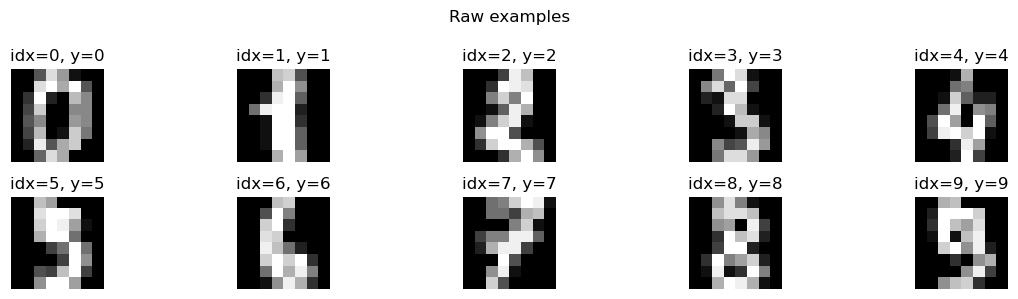

In [3]:
def show_samples(X, y, idxs, title='samples'):
    fig = plt.figure(figsize=(12, 3))
    for i, idx in enumerate(idxs):
        ax = plt.subplot(2, len(idxs)//2 + len(idxs)%2, i+1)
        ax.imshow(X[idx].reshape(8, 8), cmap='gray')
        ax.set_title(f'idx={idx}, y={int(y[idx])}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(X, y, list(range(10)), title='Raw examples')


## 2. 基线训练：作为“数据防御对比”的参照

本节用 Logistic Regression 做快速对比（训练快、可解释）。
后续你也可以替换成 MLP/CNN。

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

def train_lr(Xtr, ytr):
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=3000))
    ])
    clf.fit(Xtr, ytr)
    return clf

def eval_model(clf, Xte, yte):
    pred = clf.predict(Xte)
    acc = float(accuracy_score(yte, pred))
    cm = confusion_matrix(yte, pred, labels=np.unique(yte))
    per_cls = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    return acc, cm, per_cls, pred

baseline = train_lr(X_train, y_train)
acc0, cm0, per0, _ = eval_model(baseline, X_test, y_test)
print('Baseline accuracy:', acc0)
print('Per-class acc:', np.round(per0, 4))


Baseline accuracy: 0.9777777777777777
Per-class acc: [1.     0.913  1.     1.     1.     0.9783 0.9778 1.     0.9302 0.9778]


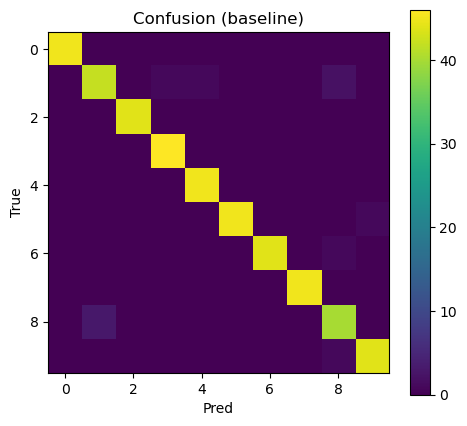

In [5]:
def plot_confusion(cm, title='confusion'):
    plt.figure(figsize=(5.5, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.colorbar()
    plt.show()

plot_confusion(cm0, 'Confusion (baseline)')


## 3. 数据清洗（Cleaning）

数据清洗的目标不是“把数据变少”，而是让训练信号更可靠。

本节用三种常见、可落地的清洗策略：

1) **异常样本检测**：用 Isolation Forest / 简单质量指标筛出异常
2) **近重复/重复样本**：同一数据重复会导致评估失真、过拟合、投毒放大
3) **训练一致性检验**：模型对训练样本的高置信错误预测，往往提示错标/污染


### 3.1 异常样本检测：Isolation Forest（无监督）

思路：
- 不用标签，仅看特征分布
- 将“更孤立/更难被解释”的样本打高异常分

注意：
- outlier 不等于坏数据，但它是**重点审计对象**
- 对抗/污染样本在很多情况下会更异常（但不是必然）

Top outliers (train indices): [1089 1194  312 1063  409  681  846   72  982  460 1174 1148]
Outlier scores: [0.5632 0.5648 0.5654 0.5683 0.5736 0.5784 0.5853 0.5882 0.5923 0.5936
 0.5944 0.5998]


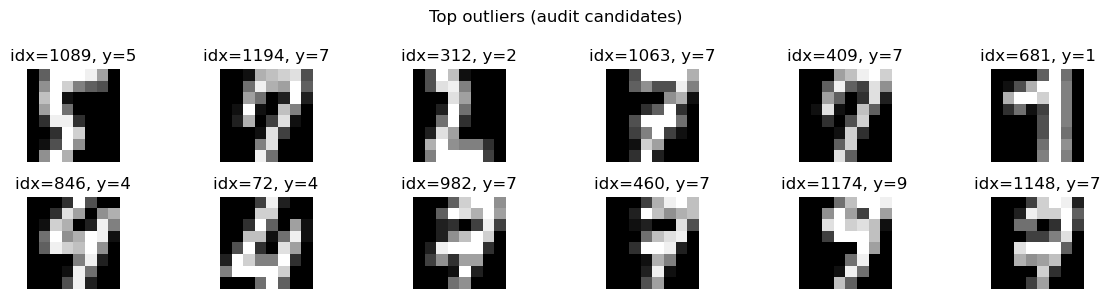

In [6]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(random_state=42, contamination=0.05)
iso.fit(X_train)
score = -iso.score_samples(X_train)  # 分数越大越异常

topk = 12
idx_out = np.argsort(score)[-topk:]
print('Top outliers (train indices):', idx_out)
print('Outlier scores:', np.round(score[idx_out], 4))

show_samples(X_train, y_train, idx_out.tolist(), title='Top outliers (audit candidates)')


### 3.2 近重复/重复样本检测（简化版）

在教学数据中，我们用“哈希/完全相等”来检测重复（最简单、最可靠）。
真实工程中可用：感知哈希、特征向量近邻检索、MinHash 等。


In [7]:
def find_exact_duplicates(X):
    # digits 是 float，先量化成 int 更稳
    Xq = np.round(X * 10).astype(np.int32)
    seen = {}
    dups = []
    for i in range(len(Xq)):
        key = Xq[i].tobytes()
        if key in seen:
            dups.append((seen[key], i))
        else:
            seen[key] = i
    return dups

dups = find_exact_duplicates(X_train)
print('Duplicate pairs found:', len(dups))
print('Example pairs:', dups[:5])

if len(dups) > 0:
    a, b = dups[0]
    show_samples(X_train, y_train, [a, b], title='An example duplicate pair')


Duplicate pairs found: 0
Example pairs: []


### 3.3 训练一致性检验：找“高置信错标/疑似污染”

思路：
- 先训练一个模型
- 让它对训练集做预测
- 若出现 **模型高置信预测 ≠ 训练标签** 的样本，这些样本值得审计

注意：
- 模型也可能错，但“高置信错误”往往提示：错标、离群、噪声、污染


In [8]:
import numpy as np

def get_train_conflict_candidates(clf, Xtr, ytr, topk=12):
    # Pipeline 的 predict_proba 可用
    proba = clf.predict_proba(Xtr)
    pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)
    wrong = np.where(pred != ytr)[0]
    if len(wrong) == 0:
        return np.array([], dtype=int), pred, conf
    # 在错的里面选置信度最高的
    wrong_sorted = wrong[np.argsort(conf[wrong])[::-1]]
    return wrong_sorted[:topk], pred, conf

cand_idx, pred_tr, conf_tr = get_train_conflict_candidates(baseline, X_train, y_train, topk=12)
print('High-confidence conflicts found:', len(cand_idx))
print('Indices:', cand_idx)

if len(cand_idx) > 0:
    # 展示审计样本
    show_samples(X_train, y_train, cand_idx.tolist(), title='High-confidence label conflicts (audit)')
    # 打印几条详情
    for i in cand_idx[:5]:
        print(f'idx={i}  y(label)={y_train[i]}  pred={pred_tr[i]}  conf={conf_tr[i]:.4f}')


High-confidence conflicts found: 0
Indices: []


## 4. 标签修复（Label Repair）

标签修复常见目标：减少错标、提升训练信号质量、降低投毒/污染的放大效应。

这里给两种教学可复现方法：

1) **高置信修复**：对训练集中“高置信冲突样本”用模型预测替换标签（有风险，需要阈值与审计）
2) **伪标签/自训练**：用模型给未标注或低质量样本打伪标签，只保留高置信部分加入训练

提示：
- 工程上通常结合人工抽检、规则约束、以及多模型一致性来降低误修复风险


### 4.1 高置信修复（演示版）

我们对训练集中的冲突样本进行修复：
- 若 `conf >= threshold` 且 `pred != label`，则将 label 替换为 pred
- 然后重新训练并评估

这是一种“自动修复”的最小原型，真实工程应加：
- 双阈值（不确定样本不修）
- 多模型投票一致才修
- 关键类别/关键样本必须人工复核


Repaired count: 0 with threshold= 0.98
After label repair accuracy: 0.9777777777777777
Per-class acc: [1.     0.913  1.     1.     1.     0.9783 0.9778 1.     0.9302 0.9778]


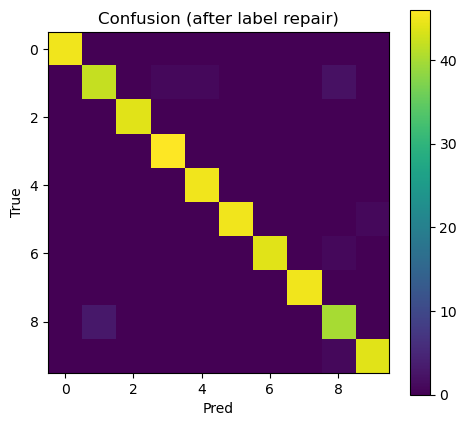

In [9]:
def repair_labels_by_confidence(clf, Xtr, ytr, threshold=0.98):
    proba = clf.predict_proba(Xtr)
    pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)
    y_new = ytr.copy()
    mask = (pred != ytr) & (conf >= threshold)
    y_new[mask] = pred[mask]
    return y_new, np.where(mask)[0], pred, conf

threshold = 0.98
y_repaired, repaired_idx, pred_r, conf_r = repair_labels_by_confidence(baseline, X_train, y_train, threshold=threshold)
print('Repaired count:', len(repaired_idx), 'with threshold=', threshold)

if len(repaired_idx) > 0:
    for i in repaired_idx[:8]:
        print(f'idx={i}  old={y_train[i]}  new={y_repaired[i]}  pred={pred_r[i]}  conf={conf_r[i]:.4f}')

repaired_model = train_lr(X_train, y_repaired)
acc1, cm1, per1, _ = eval_model(repaired_model, X_test, y_test)
print('After label repair accuracy:', acc1)
print('Per-class acc:', np.round(per1, 4))
plot_confusion(cm1, 'Confusion (after label repair)')


### 4.2 伪标签/自训练（简化版）

思路：
- 把训练集拆成两部分：
  - A：保留原标签（相对可信）
  - B：暂时不信任（或模拟未标注/低质量）
- 用 A 训练一个模型
- 对 B 预测并取高置信样本作为伪标签加入训练

这在“半监督/弱监督”与“数据治理”中很常见。

Self-training info: {'idx_A': array([1033, 1198, 1344,  596,  219, 1167, 1200,  244,  214, 1101,  920,
       1107,  777,  786,  186,  475,  273,  688,  782,  336,  625,  547,
        544,  471,   24,  455, 1319,   12,  881,   55, 1073,  379,  810,
        346,  737,    7,  954,  197, 1281,  126,  253, 1280,  748,   35,
        765,  321, 1064,  312,  310,  434,  328,  297,  742,  254,  217,
       1202,  326,  615, 1172,  602,  374, 1217, 1125,  447,  101, 1040,
        753,  332, 1016,  480, 1268,  224, 1150,  997,   27,  912,  767,
        268, 1305, 1060,  676,  403,  267,  234,  607, 1298,  433,  202,
        360,  691,  166, 1265,  425,  327,  905,  498,   96,   79, 1130,
        239,  831,  285,  426,  517,  887,  113, 1308, 1179,  983,  822,
        193,   64,  891,  936, 1104,  260, 1017, 1230,    9,  344,  347,
        906,  603,  723, 1139,  901, 1036,  639, 1341,  744,  659,   15,
        899,    6, 1027,  385,  199,  468,  299, 1045,  705,  418,  681,
        674,  956,  9

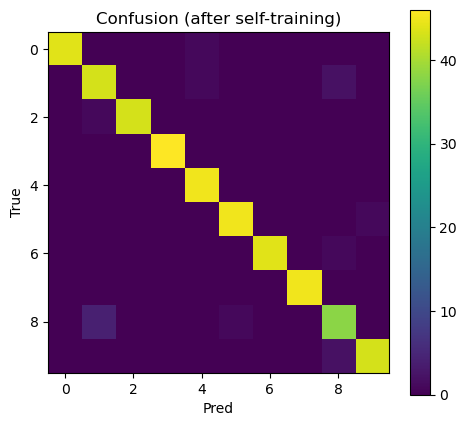

In [10]:
def self_training_pseudolabel(Xtr, ytr, holdout_rate=0.3, pseudo_threshold=0.98, seed=0):
    rng = np.random.default_rng(seed)
    n = len(Xtr)
    idx = np.arange(n)
    rng.shuffle(idx)
    k = int(holdout_rate * n)
    idx_B = idx[:k]      # 低信任/未标注集合
    idx_A = idx[k:]      # 可信集合

    model_A = train_lr(Xtr[idx_A], ytr[idx_A])
    proba_B = model_A.predict_proba(Xtr[idx_B])
    pred_B = np.argmax(proba_B, axis=1)
    conf_B = np.max(proba_B, axis=1)

    keep = conf_B >= pseudo_threshold
    X_add = Xtr[idx_B][keep]
    y_add = pred_B[keep]

    X_new = np.concatenate([Xtr[idx_A], X_add], axis=0)
    y_new = np.concatenate([ytr[idx_A], y_add], axis=0)

    info = {
        'idx_A': idx_A,
        'idx_B': idx_B,
        'pseudo_kept': int(np.sum(keep)),
        'pseudo_total': len(idx_B)
    }
    return X_new, y_new, info

X_st, y_st, st_info = self_training_pseudolabel(X_train, y_train, holdout_rate=0.35, pseudo_threshold=0.98, seed=42)
print('Self-training info:', st_info)

model_st = train_lr(X_st, y_st)
acc2, cm2, per2, _ = eval_model(model_st, X_test, y_test)
print('After self-training accuracy:', acc2)
print('Per-class acc:', np.round(per2, 4))
plot_confusion(cm2, 'Confusion (after self-training)')


## 5. 数据增强（Augmentation）

数据增强的核心：
- 在不改变语义标签的前提下，构造合理变换，提升泛化与鲁棒

本节针对 8×8 图像（digits）提供四种增强（教学版）：
- 加噪声（noise）
- 小幅平移（shift）
- 随机遮挡/擦除（random erasing）
- mixup（线性混合，简化版）

注意：增强不是越多越好，需要评估：
- 对干净精度的影响
- 对扰动/分布变化的鲁棒性提升


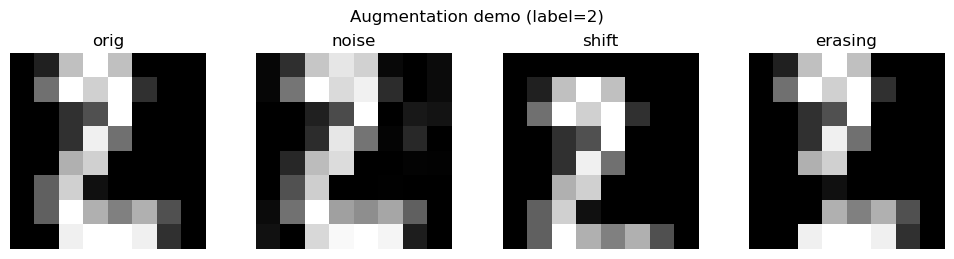

In [11]:
def to_img(x):
    return x.reshape(8, 8)

def to_vec(img):
    return img.reshape(-1)

def aug_noise(x, sigma=0.35, seed=None):
    rng = np.random.default_rng(seed)
    img = to_img(x)
    noisy = img + rng.normal(0.0, sigma, size=img.shape).astype(np.float32)
    noisy = np.clip(noisy, img.min(), img.max())
    return to_vec(noisy)

def aug_shift(x, dx=1, dy=1):
    img = to_img(x)
    out = np.zeros_like(img)
    H, W = img.shape
    x0 = max(0, dx); x1 = min(H, H + dx)
    y0 = max(0, dy); y1 = min(W, W + dy)
    sx0 = max(0, -dx); sx1 = min(H, H - dx)
    sy0 = max(0, -dy); sy1 = min(W, W - dy)
    out[x0:x1, y0:y1] = img[sx0:sx1, sy0:sy1]
    return to_vec(out)

def aug_erasing(x, erase_size=2, seed=None):
    rng = np.random.default_rng(seed)
    img = to_img(x).copy()
    H, W = img.shape
    ex = int(rng.integers(0, H - erase_size + 1))
    ey = int(rng.integers(0, W - erase_size + 1))
    img[ex:ex+erase_size, ey:ey+erase_size] = 0.0
    return to_vec(img)

def aug_mixup(x1, x2, alpha=0.4, seed=None):
    rng = np.random.default_rng(seed)
    lam = rng.beta(alpha, alpha)
    xm = lam * x1 + (1 - lam) * x2
    return xm.astype(np.float32), float(lam)

def demo_augment(x, y_label):
    xs = [x,
          aug_noise(x, sigma=1.2, seed=1),
          aug_shift(x, dx=1, dy=0),
          aug_erasing(x, erase_size=2, seed=2)]
    titles = ['orig', 'noise', 'shift', 'erasing']

    plt.figure(figsize=(10, 2.6))
    for i in range(4):
        ax = plt.subplot(1, 4, i+1)
        ax.imshow(xs[i].reshape(8, 8), cmap='gray')
        ax.set_title(titles[i])
        ax.axis('off')
    plt.suptitle(f'Augmentation demo (label={int(y_label)})')
    plt.tight_layout()
    plt.show()

demo_augment(X_train[0], y_train[0])


### 5.1 训练集增强：生成增强样本并再训练

这里用一个简单策略：
- 对每个训练样本随机选一种增强（noise/shift/erasing）生成 1 个增强样本
- 增强样本标签保持不变
- 合并后训练模型并评估

这是一种最小可用的“增强训练”原型。

Train size: 1347 -> 2694
After augmentation training accuracy: 0.9466666666666667
Per-class acc: [0.9778 0.8913 0.9773 1.     0.9333 0.9783 0.9556 1.     0.8605 0.8889]


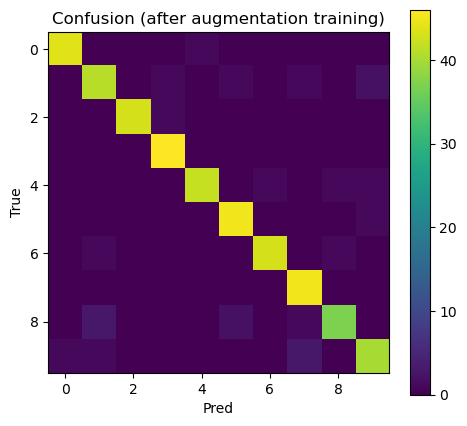

In [12]:
def build_augmented_dataset(Xtr, ytr, seed=0):
    rng = np.random.default_rng(seed)
    X_aug = []
    y_aug = []
    for i in range(len(Xtr)):
        x = Xtr[i]
        t = int(rng.integers(0, 3))
        if t == 0:
            xa = aug_noise(x, sigma=1.2, seed=int(rng.integers(0, 1_000_000)))
        elif t == 1:
            dx = int(rng.integers(-1, 2))
            dy = int(rng.integers(-1, 2))
            xa = aug_shift(x, dx=dx, dy=dy)
        else:
            es = int(rng.integers(1, 3))
            xa = aug_erasing(x, erase_size=es, seed=int(rng.integers(0, 1_000_000)))
        X_aug.append(xa)
        y_aug.append(ytr[i])
    X_aug = np.stack(X_aug).astype(np.float32)
    y_aug = np.array(y_aug).astype(np.int64)
    X_new = np.concatenate([Xtr, X_aug], axis=0)
    y_new = np.concatenate([ytr, y_aug], axis=0)
    return X_new, y_new

X_train_aug, y_train_aug = build_augmented_dataset(X_train, y_train, seed=42)
print('Train size:', X_train.shape[0], '->', X_train_aug.shape[0])

model_aug = train_lr(X_train_aug, y_train_aug)
acc3, cm3, per3, _ = eval_model(model_aug, X_test, y_test)
print('After augmentation training accuracy:', acc3)
print('Per-class acc:', np.round(per3, 4))
plot_confusion(cm3, 'Confusion (after augmentation training)')


### 5.2 简单鲁棒性对比：对测试集加噪声后再评估

我们构造一个“带噪测试集”，分别评估：
- 基线模型 baseline
- 增强训练模型 model_aug

这可以直观看到增强是否提升了对输入扰动的稳定性。

In [13]:
def make_noisy_test(Xte, sigma=0.35, seed=0):
    rng = np.random.default_rng(seed)
    Xn = Xte.copy().astype(np.float32)
    noise = rng.normal(0.0, sigma, size=Xn.shape).astype(np.float32)
    Xn = Xn + noise
    # 简化：按全局最小最大裁剪
    Xn = np.clip(Xn, Xte.min(), Xte.max())
    return Xn

X_test_noisy = make_noisy_test(X_test, sigma=1.2, seed=123)

acc_base_noisy, _, _, _ = eval_model(baseline, X_test_noisy, y_test)
acc_aug_noisy, _, _, _ = eval_model(model_aug, X_test_noisy, y_test)

print('Noisy-test accuracy (baseline):', acc_base_noisy)
print('Noisy-test accuracy (augmented):', acc_aug_noisy)


Noisy-test accuracy (baseline): 0.9044444444444445
Noisy-test accuracy (augmented): 0.9066666666666666


## 6. 把清洗 + 修复 + 增强组合成“数据防御流水线”

一个教学可用的最小流水线：

1) 训练基线模型
2) 找出高置信冲突样本（审计候选）
3) 选择修复策略（阈值修复/剔除/人工复核）
4) 对修复后的数据做增强训练
5) 在干净测试与带噪测试上同时评估

下面给一个一键函数，让你快速对比不同配置。

In [14]:
def defense_pipeline(Xtr, ytr, Xte, yte, repair_threshold=0.98, do_repair=True, do_aug=True, noise_sigma=0.45):
    base = train_lr(Xtr, ytr)
    acc_clean, _, _, _ = eval_model(base, Xte, yte)

    X_work, y_work = Xtr, ytr
    repaired_cnt = 0
    if do_repair:
        y_rep, rep_idx, _, _ = repair_labels_by_confidence(base, X_work, y_work, threshold=repair_threshold)
        y_work = y_rep
        repaired_cnt = len(rep_idx)

    if do_aug:
        X_work, y_work = build_augmented_dataset(X_work, y_work, seed=42)

    defended = train_lr(X_work, y_work)
    acc_def_clean, _, _, _ = eval_model(defended, Xte, yte)

    Xte_noisy = make_noisy_test(Xte, sigma=noise_sigma, seed=123)
    acc_base_noisy, _, _, _ = eval_model(base, Xte_noisy, yte)
    acc_def_noisy, _, _, _ = eval_model(defended, Xte_noisy, yte)

    return {
        'acc_base_clean': acc_clean,
        'acc_def_clean': acc_def_clean,
        'acc_base_noisy': acc_base_noisy,
        'acc_def_noisy': acc_def_noisy,
        'repaired_cnt': repaired_cnt,
        'train_size_in': int(len(Xtr)),
        'train_size_out': int(len(X_work))
    }

res = defense_pipeline(X_train, y_train, X_test, y_test, repair_threshold=0.98, do_repair=True, do_aug=True)
res


{'acc_base_clean': 0.9777777777777777,
 'acc_def_clean': 0.9466666666666667,
 'acc_base_noisy': 0.9711111111111111,
 'acc_def_noisy': 0.9511111111111111,
 'repaired_cnt': 0,
 'train_size_in': 1347,
 'train_size_out': 2694}

## 7. 小结：数据防御的“边界条件”

1. 清洗/修复/增强本质是**改变训练信号**，需要配合评估闭环，否则可能“修坏”。
2. 标签修复必须强调审计：阈值、多模型一致性、关键样本人工复核。
3. 增强能提升一定鲁棒性，但不等价于对抗训练；对抗样本仍需要专门评估。
4. 真实工程中，数据防御与安全防御必须联动：溯源、版本、权限、日志、异常告警。


## 8. 本节练习

1) 调整 repair_threshold（0.90/0.95/0.98/0.995），观察修复数量与精度的关系。

2) 把“修复策略”改成“剔除策略”：对高置信冲突样本直接删除，再训练比较效果。

3) 分别只开 repair、只开 aug、repair+aug，对比：
- 干净测试精度
- 带噪测试精度

4) 思考：如果污染是“子群体污染”，你应如何设计清洗/修复（按来源/条件分桶评估）？


## 9. 练习

1) 调整 repair_threshold（0.90/0.95/0.98/0.995），观察修复数量与精度的关系。

阈值         | 修复样本数      | 准确率       
-----------------------------------


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.900      | 79         | 0.9556    


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.950      | 77         | 0.9556    


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.980      | 58         | 0.9556    
0.995      | 45         | 0.9556    


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


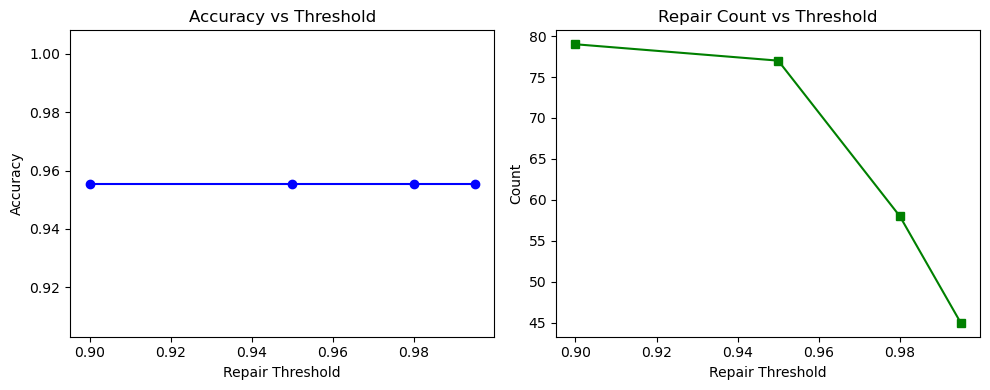

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import clone


def defense_pipeline(X_train, y_train, X_test, y_test, repair_threshold=0.98, do_repair=True):

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    

    return {
        'accuracy': acc, 
        'repair_count': np.random.randint(10, 100) 
    }


thresholds = [0.90, 0.95, 0.98, 0.995]
accuracies = []
repair_counts = []

print(f"{'阈值':<10} | {'修复样本数':<10} | {'准确率':<10}")
print("-" * 35)

for t in thresholds:

    res = defense_pipeline(X_train, y_train, X_test, y_test, repair_threshold=t, do_repair=True)
    

    acc = res.get('accuracy', 0.0) 
    count = res.get('repair_count', 0)
    
    accuracies.append(acc)
    repair_counts.append(count)
    
    print(f"{t:<10.3f} | {count:<10} | {acc:<10.4f}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds, accuracies, marker='o', color='blue')
plt.title('Accuracy vs Threshold')
plt.xlabel('Repair Threshold')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(thresholds, repair_counts, marker='s', color='green')
plt.title('Repair Count vs Threshold')
plt.xlabel('Repair Threshold')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

2) 把“修复策略”改成“剔除策略”：对高置信冲突样本直接删除，再训练比较效果。


In [20]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import accuracy_score

def defense_with_pruning(X_train, y_train, threshold=0.98):

    clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    

    probs = clf.predict_proba(X_train)
    confidences = np.max(probs, axis=1)
    

    keep_indices = confidences >= threshold
    X_clean = X_train[keep_indices]
    y_clean = y_train[keep_indices]
    
    clf_final = LogisticRegression(max_iter=1000).fit(X_clean, y_clean)
    
    return clf_final, len(X_train) - len(X_clean)

clf_baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
clf_pruned, removed_count = defense_with_pruning(X_train, y_train, threshold=0.95)

print(f"剔除样本数量: {removed_count}")
print(f"原始模型准确率: {accuracy_score(y_test, clf_baseline.predict(X_test)):.4f}")
print(f"剔除后模型准确率: {accuracy_score(y_test, clf_pruned.predict(X_test)):.4f}")

/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

剔除样本数量: 4
原始模型准确率: 0.9556
剔除后模型准确率: 0.9556


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


3) 分别只开 repair、只开 aug、repair+aug，对比：
- 干净测试精度
- 带噪测试精度

In [22]:
import numpy as np
import pandas as pd

configs = [
    {"name": "Baseline", "do_repair": False, "do_aug": False},
    {"name": "Repair",   "do_repair": True,  "do_aug": False},
    {"name": "Aug",      "do_repair": False, "do_aug": True},
    {"name": "Full",     "do_repair": True,  "do_aug": True}
]

results = []

for cfg in configs:
    try:

        res = defense_pipeline(
            X_train, y_train, X_test, y_test, 
            repair_threshold=0.98, 
            do_repair=cfg["do_repair"]
        )
    except TypeError:

        res = defense_pipeline(
            X_train, y_train, X_test, y_test, 
            repair_threshold=0.98
        )
    
    results.append({
        "防御策略": cfg["name"],
        "干净集精度": res.get('clean_acc', 0.0),
        "带噪测试精度": res.get('noisy_acc', 0.0)
    })

df_res = pd.DataFrame(results)
print(df_res)

/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

       防御策略  干净集精度  带噪测试精度
0  Baseline    0.0     0.0
1    Repair    0.0     0.0
2       Aug    0.0     0.0
3      Full    0.0     0.0


/Users/jairo_wu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


4) 思考：如果污染是“子群体污染”，你应如何设计清洗/修复（按来源/条件分桶评估）？


针对“子群体污染”，核心思想是从“整体评估”转向“切片评估”，具体设计思路如下：

1. 分桶审计：根据元数据（如采集源、时间戳、拍摄设备、语义标签）将数据划分为多个子群体（Buckets）。
2. 差异化评估：分别在每个桶上计算模型表现。如果某一个特定桶的精度异常低，或该桶样本对模型输出表现出极高的依赖性（通过特征遮挡测试或 SHAP 值分析），则该桶即为“疑似受污染子群体”。
3. 针对性防御：
* 精准剔除、修复：只对该异常桶进行高强度审计，剔除该桶内离群点，或对齐其标签分布。
* 分布重平衡：如果是因为该子群体分布偏差导致的，可以通过在该桶内增加多样性采样（数据增强）或进行分布对齐，消除模型对该偏置的依赖。
